# Les raisons d'utiliser l'IA

Dans ce notebook, nous utilisons l'algorithme Bertopic pour identifier les "raisons" présentées par les enquêtées pour expliquer leur usage de l'IA.

In [1]:
import pandas as pd
import re
import os #pour naviguer dans les dossiers
from io import StringIO
import s3fs #pour connecter au bucket
import scipy.stats

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:


# Create filesystem object
S3_ENDPOINT_URL = "https://" + os.environ["AWS_S3_ENDPOINT"]
fs = s3fs.S3FileSystem(client_kwargs={'endpoint_url': S3_ENDPOINT_URL})

BUCKET_OUT = "aluneau"

last_file="anonymous_answer_2026-07-24.csv"


In [3]:
with fs.open(f"{BUCKET_OUT}/data_eP8/raw/{last_file}", "r") as file_in:
    df0 = pd.read_csv(file_in, sep =",")


df0 = df0.loc[~df0.q45_clé.isin(["9EAP-NB4B","QNYZ-3MH2"])]

In [4]:

df_col = pd.read_csv("../le_questionnaire/dico_variable.csv", sep = ",")


In [5]:
list_nominal_simple = [x for x in df_col.label.loc[(df_col.type.isin(["simple_nominal", "booléen","ordinal"]))]]


In [6]:
def split_multiple_choices(data, column, index, sep = '|'):
    """
    split and explode column with multiple value

    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_split = data.copy()
    df_split[column]= df_split.apply(lambda row: row[column].replace(";",sep) ,1 )
    df_split[column] = df_split[column].str.split(sep)
    df_explode = df_split.explode(column)
    gb_data = df_explode.groupby([column]).agg(nb = (index, "size")).sort_values("nb", ascending=False).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100
    
    return df_explode, gb_data
    

In [7]:
def grouped_question(data, column, index = "q45_clé"):
    """


    data = a panda dataframe
    column = name of column which we want to split.
    index = column corresponding to id of rows
    sep = by default '|'. Character use to separate values.
    """
    df_tmp = data.copy()
    gb_data = df_tmp.groupby([column]).agg(nb = (index, "size")).reset_index()
    gb_data["total"] = data[index].nunique()
    gb_data["freq"] = gb_data.nb/gb_data.total*100
    gb_data["total_freq"] = gb_data.total/gb_data.total*100

    return gb_data

In [8]:
def tab_croise(data, x, y, regroup_y = True, khideux = False) :
    """
    x = variable en ligne
    y = variable en colonne
    """
    if regroup_y == True:

        data.loc[data[y].str.lower().str.contains("oui"), f"{y}_rec"] = "Oui"
        data.loc[data[y].str.lower().str.contains("non"), f"{y}_rec"] = "Non"

        cross_tab = pd.crosstab(data[x], data[f"{y}_rec"], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[f"{y}_rec"], margins = False)
    else:
        cross_tab = pd.crosstab(data[x], data[y], margins = True, margins_name="Total", normalize=False)
        cross_tab0 = pd.crosstab(data[x], data[y], margins = False, normalize=False)

    if khideux == True:
        print(scipy.stats.chi2_contingency(cross_tab0))
        st_chi2, st_p, st_dof, st_exp = scipy.stats.chi2_contingency(cross_tab0)
        chi2 = pd.DataFrame(data={"stats":["chi2","df","p-value"], "values":[st_chi2, st_dof, st_p]})
        cross_tab = pd.concat([cross_tab, chi2])
    else:
        pass

    return cross_tab.fillna("").reset_index(), cross_tab0

In [9]:
!python -m spacy download fr_core_news_md

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/45.8 MB ? eta -:--:--

     ━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━ 20.7/45.8 MB 116.3 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━ 43.8/45.8 MB 113.8 MB/s eta 0:00:01

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 MB 99.8 MB/s  0:00:00


✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_md')


In [10]:
import spacy
import re
import bertopic

import nltk
from nltk.corpus import stopwords

In [11]:
nlp = spacy.load('fr_core_news_md')
nlp.add_pipe("merge_entities")
#nlp.add_pipe("merge_noun_chunks")
spacy_stopwords = list(nlp.Defaults.stop_words)




nltk.download('stopwords')

spacy_stopwords
stop_words = set(stopwords.words('french'))


[nltk_data] Downloading package stopwords to /home/onyxia/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [239]:
#
pos=['VERB','ADJ','ADV']
df_ia = df0[["q45_clé","q35_ia_tools","q37_raison_util_ia"]].loc[~df0.q37_raison_util_ia.isna()]
dict_sent = {}
for n, x in enumerate(df_ia.q35_ia_tools):
    doc = nlp(x)
    if len([t.text.lower() for t in doc if t.pos_ in pos]) >=2:
        print(x)
        id_user = df_ia.q45_clé.iloc[n]
        dict_sent[id_user] = x
    

Intelligence Artificielle désigne de nombreuses technologies. Je n'utilise pas d'outils génératifs mais je travaille avec et développe des outils de transcription, d'analyse de texte et de la parole, d'analyse d'image. Il s'agit de logiciels qui tournent en local sur mon matériel.
DeepL - objection de conscience par rapport à l'IA générative
NoScribe en local pour des transcriptions d'entretiens + deepl pour des traductions courtes et ponctuelles.
Deep L, Coco SSD dans le cadre d'un projet de recherche, parfois Chat GPT pour tester les éventuels usages dans des travaux des étudiant.es
très peu ; chat GPT mais je l'utilise très peu car ce n'est pas un compte pro; je préfère attendre que l'on ait des recommandations en terme d'utilisation de l'IA par l'université, avec peut être un compte pro pour protéger le contenu dépose ; j'utilise par contre deep pour une aide à la traduction


Je participe à deux projets de recherche qui utilisent ce type d'outil


In [240]:
dict_new_sent = {}
for n, x in enumerate(df_ia.q37_raison_util_ia):
    id_user= df_ia.q45_clé.iloc[n]
    if id_user in dict_sent.keys():
        new_sent = ". ".join([dict_sent[id_user], x])
    else:
        new_sent = x

    dict_new_sent[id_user]= new_sent

dict_new_sent


{'FCCB-GMYA': 'Pédagogie, Recherche (biblio)',
 'CV3G-95CT': "relecture de l'anglais principalement",
 'M5L8-UM9F': 'aide ponctuelle formulation de traduction, aide ponctuelle réponses à des questions méthodologiques complexes',
 '9K9T-RVNL': 'Principalement pour alléger ma charge de travail : rechercher des informations méthodologique ou statistiques, relire ma production en anglais, améliorer des formulations, rédiger des mails de réponse, rédiger des post professionnels pour les réseaux sociaux, etc.',
 'CN6B-UEHQ': "Intelligence Artificielle désigne de nombreuses technologies. Je n'utilise pas d'outils génératifs mais je travaille avec et développe des outils de transcription, d'analyse de texte et de la parole, d'analyse d'image. Il s'agit de logiciels qui tournent en local sur mon matériel.. Il s'agit de mon cœur de recherche. ",
 '5G5M-BM3L': 'pour rester au courant des progrès et fonctionnalités',
 'BKF8-SNEZ': 'Automatisation de tâches réccurentes, créations de site web pour d

## Preprocess text

In [241]:

df_ia["text"]=df_ia.q45_clé.map(dict_new_sent.get)
df_ia = df_ia.loc[~df_ia.text.str.lower().str.contains("cnrs")] #on enlève cette réponse qui crée du bruit

In [242]:
df_ia["clean_text"] = df_ia.apply(lambda row: str(row.text).lower().strip(), 1) # lower sentence
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"\w'", "", str(row.clean_text)), 1) #replace "\w’" by ""
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"\/", " ", str(row.clean_text)), 1) #replace "/" by " "
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"\(|\)", "", str(row.clean_text)), 1) #replace "/" by " "
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"\+", ".", str(row.clean_text)), 1) #replace "/" by " "
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"œ", "oe", str(row.clean_text)), 1) #replace "/" by " "
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"ganer", "gagner", str(row.clean_text)), 1) #replace "/" by " "
df_ia["clean_text"] = df_ia.apply(lambda row: re.sub(r"noscibe", "noscribe", str(row.clean_text)), 1) #replace "/" by " "
df_ia["split_text"] = df_ia.clean_text.str.split(".")

######### Explode

df_ia1 = df_ia.explode("split_text")
df_ia1 = df_ia1.loc[df_ia1.split_text.str.len()>2]

df_ia1["split_text"] = df_ia1.split_text.str.split(";")

######### Explode

df_ia1 = df_ia1.explode("split_text")
df_ia1 = df_ia1.loc[df_ia1.split_text.str.len()>2]
df_ia1["split_text"] = df_ia1.apply(lambda row: " ".join(re.sub("[^'a-zA-Zàâäéèêëïîôöùûüÿçß]+", " ", row.split_text).split()), 1) #remove hashtag, arobase, HTML character
df_ia1["tokens"] = df_ia1.apply(lambda row: row.split_text.split(),1) 


In [243]:
for x in df_ia1.split_text:
    if ";" in x:
        print(x)

In [244]:
df_ia1["len_txt"] = df_ia1.tokens.str.len()
df_ia1 = df_ia1.loc[df_ia1.tokens.str.len()>2].reset_index()

print(f"Il y a {len(df_ia1)} phrases. Le plus long fait {max(df_ia1.len_txt)} caractères.")


Il y a 74 phrases. Le plus long fait 37 caractères.


In [245]:
df_ia1["text_id"] = "id_" + df_ia1.index.astype(str) # on crée un id qu'on réutilisera plus bas
df_ia1
texts = [text for text in df_ia1.split_text] #liste des textes nettoyés
texts_id = [id_text for id_text in df_ia1.text_id]

In [246]:
df_ia1

,index,q45_clé,q35_ia_tools,q37_raison_util_ia,text,clean_text,split_text,tokens,len_txt,text_id
0,2,FCCB-GMYA,"Chat GPT, Mistral IA, LM Notebook","Pédagogie, Recherche (biblio)","Pédagogie, Recherche (biblio)","pédagogie, recherche biblio",pédagogie recherche biblio,"[pédagogie, recherche, biblio]",3,id_0
1,3,CV3G-95CT,"chatgpt, euria",relecture de l'anglais principalement,relecture de l'anglais principalement,relecture de anglais principalement,relecture de anglais principalement,"[relecture, de, anglais, principalement]",4,id_1
2,4,M5L8-UM9F,"Chat-GPT, Perplexity","aide ponctuelle formulation de traduction, aid...","aide ponctuelle formulation de traduction, aid...","aide ponctuelle formulation de traduction, aid...",aide ponctuelle formulation de traduction aide...,"[aide, ponctuelle, formulation, de, traduction...",13,id_2
3,8,9K9T-RVNL,le chat ; chatgpt,Principalement pour alléger ma charge de trava...,Principalement pour alléger ma charge de trava...,principalement pour alléger ma charge de trava...,principalement pour alléger ma charge de trava...,"[principalement, pour, alléger, ma, charge, de...",35,id_3
4,9,CN6B-UEHQ,Intelligence Artificielle désigne de nombreuse...,Il s'agit de mon cœur de recherche.,Intelligence Artificielle désigne de nombreuse...,intelligence artificielle désigne de nombreuse...,intelligence artificielle désigne de nombreuse...,"[intelligence, artificielle, désigne, de, nomb...",6,id_4
...,...,...,...,...,...,...,...,...,...,...
69,109,RZY3-LPES,"Chat GPT, IA associée aux App (dont Apple IA)",Gagner du temps +++,Gagner du temps +++,gagner du temps ...,gagner du temps,"[gagner, du, temps]",3,id_69
70,111,Q934-QKAW,Chat GPT ; Claude,"traduction, amélioration de l'écriture, reform...","traduction, amélioration de l'écriture, reform...","traduction, amélioration de écriture, reformul...",traduction amélioration de écriture reformulat...,"[traduction, amélioration, de, écriture, refor...",8,id_70
71,112,HKN6-95PQ,Elicit,Beaucoup plus rapide et plus précise que Scopu...,Beaucoup plus rapide et plus précise que Scopu...,beaucoup plus rapide et plus précise que scopu...,beaucoup plus rapide et plus précise que scopu...,"[beaucoup, plus, rapide, et, plus, précise, qu...",11,id_71
72,115,WAR9-LFJP,"Claude, ChatGPT",Revision de l'anglais écrit/traduction et anal...,Revision de l'anglais écrit/traduction et anal...,revision de anglais écrit traduction et analys...,revision de anglais écrit traduction et analys...,"[revision, de, anglais, écrit, traduction, et,...",10,id_72


## Décomposition de l'algorithme Bertopic

BERTopic est composé de quatre "étapes" :

   - Le plongement dans un embedding des phrases du corpus à l'aide d'un modèle sentence transformers
   - La réduction de la dimensionalité de l'embedding
   - L'extraction de clusters
   - La labellisation des clusters en utilisant c-TF-IDF

Le point essentiel à retenir est que chacune des fonctions utilisées pour réaliser ces 4 étapes possèdent des paramètres dont la définition joue ensuite sur le résultat final.

In [127]:
from sentence_transformers import SentenceTransformer
import pickle



La librairie sentence_transformers permet d'accéder facilement aux modèles hébergés sur huggingface.

pickle servira à enregistrer l'embedding pour une réutilisation ultérieure.

Une fois le modèle chargé, il peut être utile de vérifier que la taille maximale de la séquence admise par le modèle est égale ou supérieure à la taille du texte le plus long du corpus. Dans le cas contraire, les textes trop longs seront tronqués.

Le modèle que nous utilisons est 'paraphrase-multilingual-MiniLM-L12-v2'. La taille maximale de la séquence est 128, or le commentaire le plus long est 63 mots.


In [128]:
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
print("Taille maximale de la séquence : ", model.get_max_seq_length())
print(model.get_max_seq_length()>= max(df_ia1.len_txt))


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Taille maximale de la séquence :  128
True


In [138]:
embeddings = model.encode(texts, show_progress_bar=True, batch_size=32)

Batches:   0%|          | 0/3 [00:00<?, ?it/s]

### Réduction des dimensions avec UMAP



Une fois l’embedding réalisée, BERTopic fait appel à UMAP (Uniform Manifold Approximation and Projection) pour réduire le nombre de dimensions – qui est au départ de 384.

UMAP est un algorithme qui cherche à préserver la structure locale (relation entre points proches) et la structure globale des données.

    Le nombre de voisins : n_neighbors.

La balance entre la préservation des structures locales et globales est d'abord déterminée par le nombre de voisins (n_neighbors) de chaque point que l'algorithme prend en compte. Plus le n_neighbors est petit, plus UMAP préservera la structure locale des données. Inversement, plus n_neighbors est grand, plus UMAP rendra visible la structure globale au détriment des spécifités locales.

Pour saisir l'effet de n_neighbors, on peut s'amuser à tracer une série de scatterplots.


In [130]:
import umap
from tqdm.auto import tqdm

In [111]:
embeddings.shape

(74, 384)

  0%|          | 0/9 [00:00<?, ?it/s]

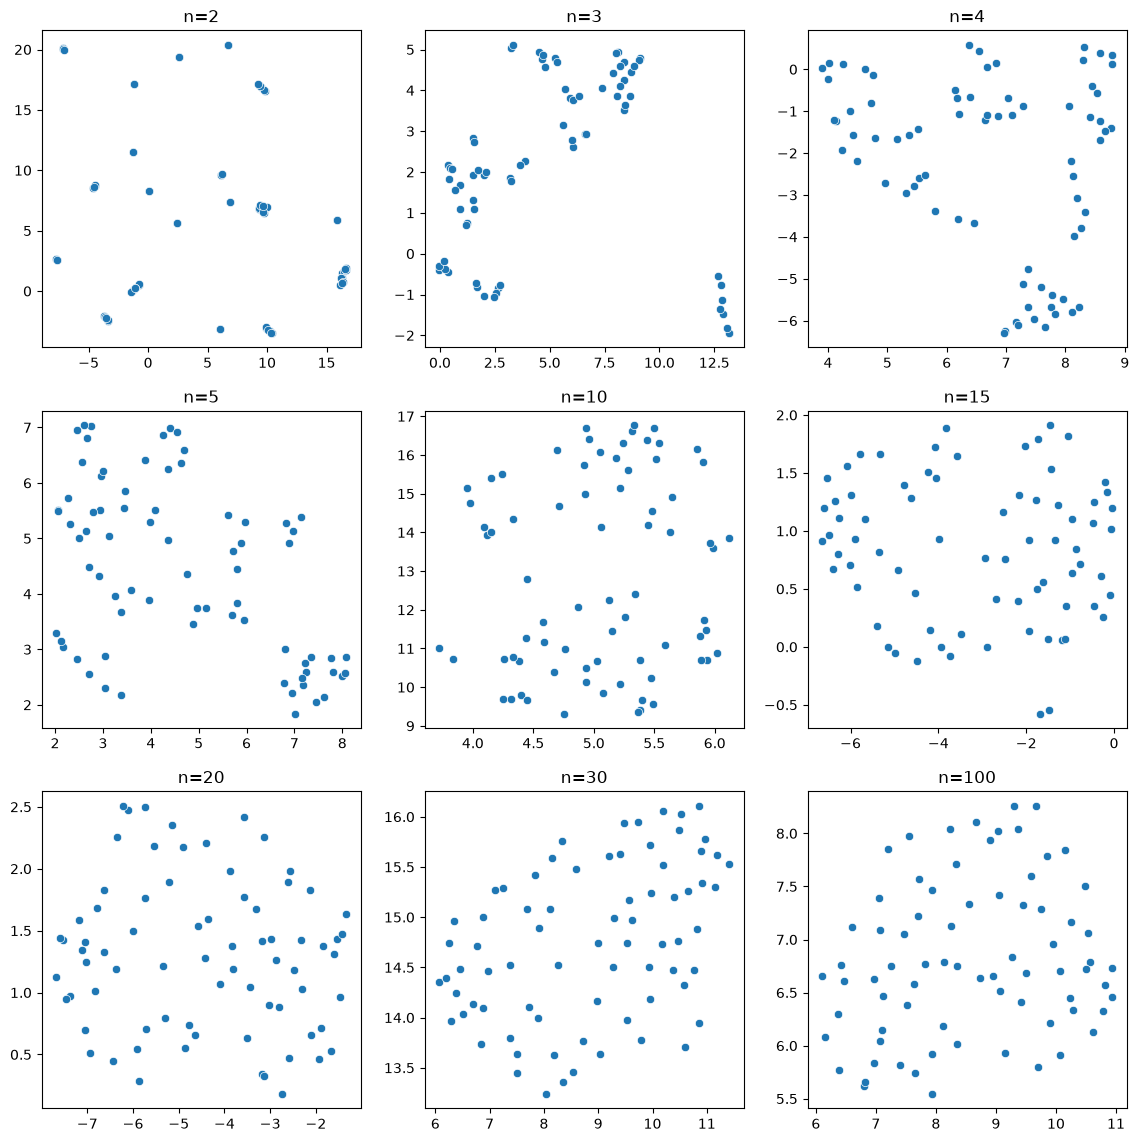

In [112]:


fig, ax = plt.subplots(3, 3, figsize=(14, 14))
nns = [2, 3, 4, 5, 10, 15, 20, 30, 100]
i, j = 0, 0
for n_neighbors in tqdm(nns):
    fit = umap.UMAP(n_neighbors=n_neighbors, min_dist=0.05, n_components=2, random_state=42, metric = 'cosine')
    u = fit.fit_transform(embeddings)
    sns.scatterplot(x=u[:,0], y=u[:,1],  ax=ax[j, i])
    ax[j, i].set_title(f'n={n_neighbors}')
    if i < 2: i += 1
    else: i = 0; j += 1



Visuellement, il semble que le nombre de voisin optimal se situe entre 2 et 4. On distingue plus facilement des grappes.

In [186]:
## parametre umap
n_neighbors=3
n_components=5
min_dist=0.00

##parametre hdbscan
min_samples=3
min_cluster_size=5

umap_model = umap.UMAP(n_neighbors=n_neighbors, 
                       n_components=n_components, 
                       min_dist=min_dist,
                       metric='cosine',
                       random_state=42).fit_transform(embeddings)

### Clusterisation avec Hdbscan

In [187]:
import hdbscan

In [188]:
labels = hdbscan.HDBSCAN(
    min_samples=min_samples,
    min_cluster_size=min_cluster_size,
    metric='euclidean',cluster_selection_method='eom', 
    gen_min_span_tree=True
).fit(umap_model)


<Axes: ylabel='distance'>

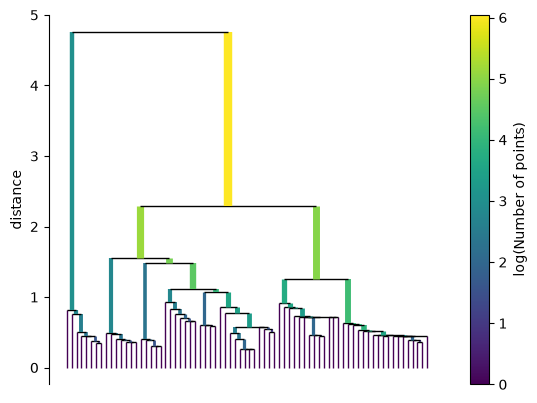

In [189]:
labels.single_linkage_tree_.plot()

In [190]:
labels.labels_

array([0, 3, 3, 5, 6, 2, 5, 6, 6, 1, 2, 6, 3, 2, 3, 2, 3, 4, 3, 1, 3, 6,
       1, 6, 3, 0, 5, 2, 3, 0, 6, 4, 0, 6, 5, 1, 3, 3, 5, 3, 6, 3, 0, 2,
       6, 6, 4, 5, 6, 6, 1, 6, 0, 1, 3, 4, 5, 2, 4, 2, 2, 0, 1, 2, 3, 3,
       2, 2, 2, 6, 3, 6, 3, 0])

In [191]:
len(set(labels.labels_))

7

In [192]:
dict_clusters = {}
for n, x in enumerate(texts):
    dict_clusters[x] = labels.labels_[n]


for x in range(-1,len(set(labels.labels_))):
    print("Cluster :", x)
    for v in dict_clusters:
        if dict_clusters[v] == x:
            print(v)

Cluster : -1
Cluster : 0
pédagogie recherche biblio
facilitation et correction
correction orthographique reformulation epicenisation
relectures améliorations du manuscrit
relecture correction extraction de données analyse de documents
elicit pour la bibliographie
assistance à la rédaction revue de littérature
fautes orthographe non vues lors des relectures
Cluster : 1
automatisation de tâches réccurentes créations de site web pour des supports pédagogiques personnalisés en ligne
deep l coco ssd dans le cadre un projet de recherche parfois chat gpt pour tester les éventuels usages dans des travaux des étudiant
pour aider à la conception exercices en cours pour aider à faire des recherches web sur des sujets précis
je préfère attendre que on ait des recommandations en terme utilisation de ia par université avec peut être un compte pro pour protéger le contenu dépose
comprendre et anticiper la façon dont les étudiants les utilisent
enseignement structuration de cours élaboration de syllab

In [193]:
umap_model = umap.UMAP(n_neighbors=n_neighbors, 
                       n_components=n_components, 
                       min_dist=min_dist,
                       metric='cosine',
                       random_state=42)

hdbscan_model =  hdbscan.HDBSCAN(
    min_samples=min_samples,
    min_cluster_size=min_cluster_size,
    metric='euclidean',
    cluster_selection_method='eom', 
    prediction_data = True,
    gen_min_span_tree=True
)



In [194]:
from bertopic.vectorizers import ClassTfidfTransformer
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer

In [195]:
vectorizer_model = CountVectorizer(ngram_range=(1, 2),
                                   strip_accents='unicode',
                                    stop_words= [x for x in nlp.Defaults.stop_words])

ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True)


In [211]:


topic_model = bertopic.BERTopic(
    language="french",
    #embedding_model= model,    # Step 1 - Extract embeddings
    umap_model=umap_model,              # Step 2 - Reduce dimensionality
    hdbscan_model=hdbscan_model,        # Step 3 - Cluster reduced embeddings
    vectorizer_model=vectorizer_model,  # Step 4 - Tokenize topics
    ctfidf_model=ctfidf_model,          # Step 5 - Extract topic words
    calculate_probabilities=True,        
    verbose=True
)



In [212]:
topics, probs = topic_model.fit_transform(texts, embeddings)

2026-09-25 08:42:48,063 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


2026-09-25 08:42:48,151 - BERTopic - Dimensionality - Completed ✓


2026-09-25 08:42:48,152 - BERTopic - Cluster - Start clustering the reduced embeddings


2026-09-25 08:42:48,161 - BERTopic - Cluster - Completed ✓


2026-09-25 08:42:48,164 - BERTopic - Representation - Fine-tuning topics using representation models.


2026-09-25 08:42:48,179 - BERTopic - Representation - Completed ✓


In [213]:
len(set(topics))

7

In [214]:
top_lab = topic_model.get_topic_info()
top_lab

,Topic,Count,Name,Representation,Representative_Docs
0,0,18,0_traduction_anglais_textes_traductions,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...
1,1,16,1_temps_gain temps_propositions_gain,"[temps, gain temps, propositions, gain, sourci...",[recherche complémentaire informations sourcin...
2,2,13,2_transcription_texte_entretiens_code,"[transcription, texte, entretiens, code, analy...",[transcription entretien aide à la rédaction a...
3,3,8,3_correction_relectures_analyse documents_assi...,"[correction, relectures, analyse documents, as...",[correction orthographique reformulation epice...
4,4,7,4_mails_rediger_statistiques_rechercher,"[mails, rediger, statistiques, rechercher, rap...",[principalement pour des aides à la programmat...
5,5,7,5_web_utilisent_pedagogiques_aider,"[web, utilisent, pedagogiques, aider, cours, a...",[automatisation de tâches réccurentes création...
6,6,5,6_ca_ca utile_comprendre fonctionnent_deeple,"[ca, ca utile, comprendre fonctionnent, deeple...",[essaye de comprendre comment ils fonctionnent...


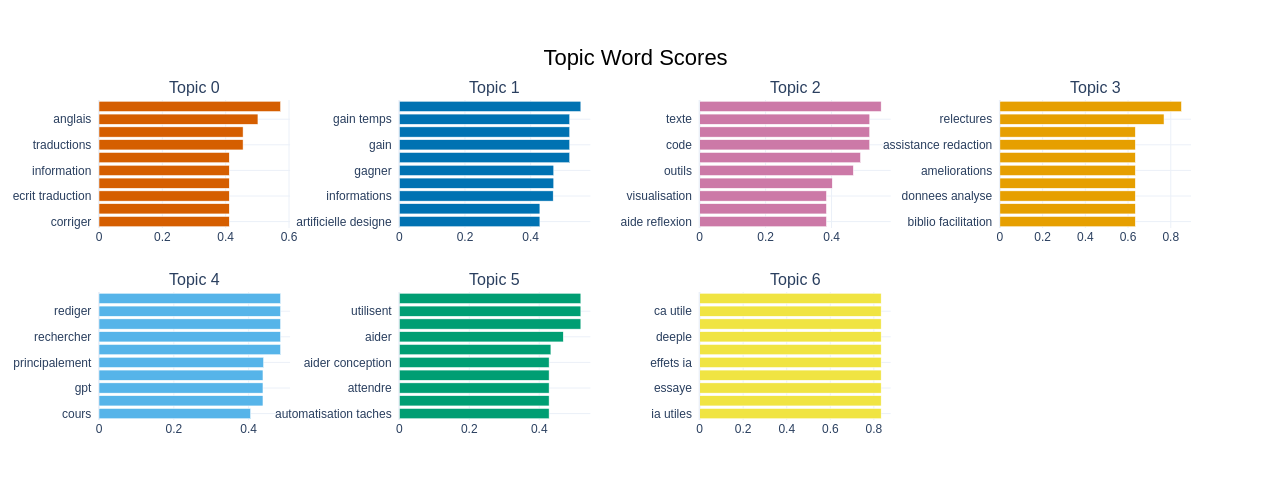

In [215]:
fig = topic_model.visualize_barchart(top_n_topics=46, n_words = 10)
fig

## Matrice de similarité et arbre hiérarchique

On regarde quels sont les topics proches et s'il peut être judicieux d'opérer des regroupements.

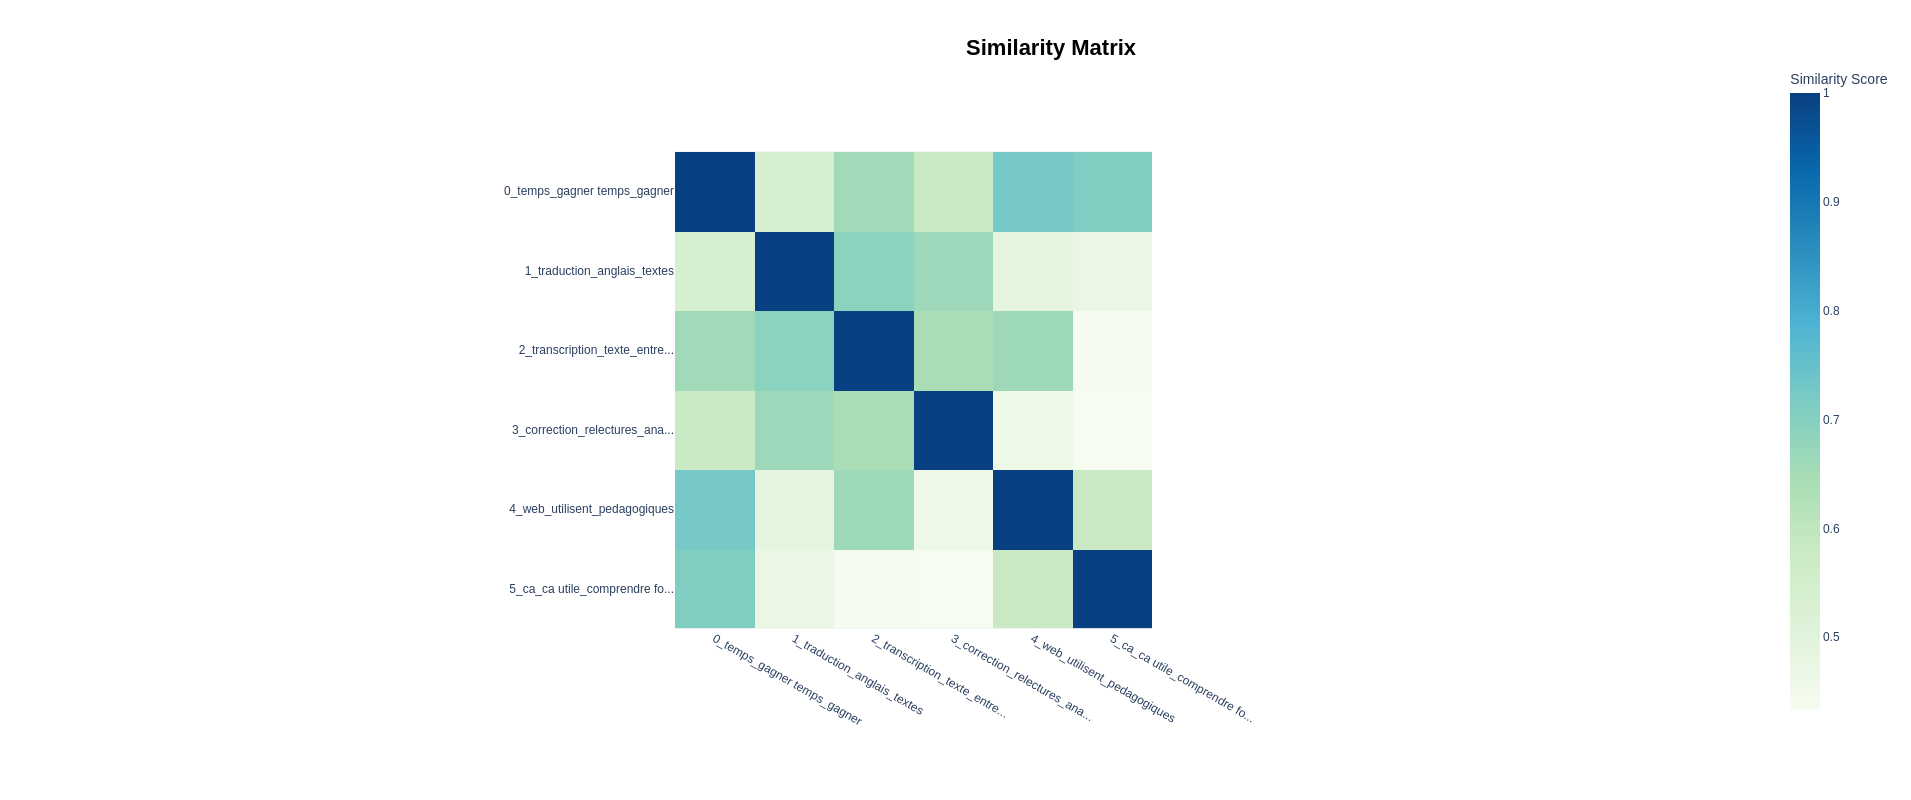

In [258]:
topic_model.visualize_heatmap()

S'il y a des topics à regrouper, on utilisera les lignes de codes ci-dessous (voir la documentation de Bertopic sur [les moyens de réduire les topics](https://maartengr.github.io/BERTopic/getting_started/topicreduction/topicreduction.html#manual-topic-reduction)):

```
topics_to_merge = [1, 2]
topic_model.merge_topics(docs, topics_to_merge)
```

  0%|          | 0/6 [00:00<?, ?it/s]

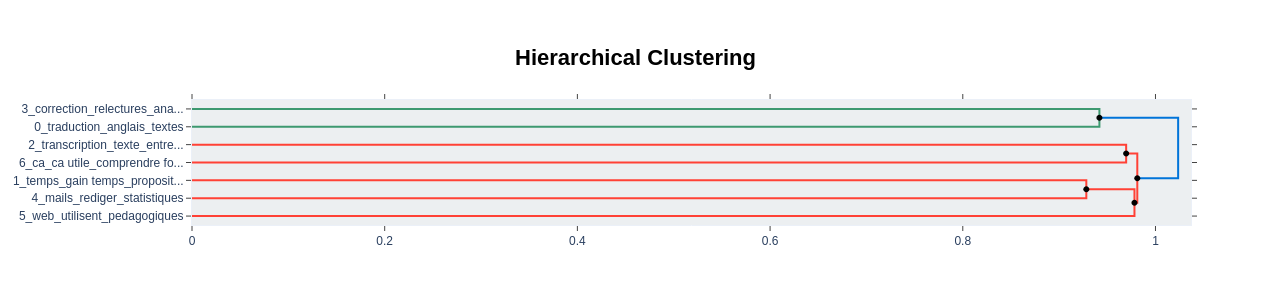

In [217]:
hierarchical_topics = topic_model.hierarchical_topics(texts)
topic_model.visualize_hierarchy(hierarchical_topics=hierarchical_topics)

In [221]:
topics_to_merge = [1, 4]
topic_model.merge_topics(texts, topics_to_merge)



In [222]:
topic_model.get_topic_info()

,Topic,Count,Name,Representation,Representative_Docs
0,0,23,0_temps_gagner temps_gagner_informations,"[temps, gagner temps, gagner, informations, pr...",[principalement pour des aides à la programmat...
1,1,18,1_traduction_anglais_textes_traductions,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...
2,2,13,2_transcription_texte_entretiens_code,"[transcription, texte, entretiens, code, analy...",[transcription entretien aide à la rédaction a...
3,3,8,3_correction_relectures_analyse documents_assi...,"[correction, relectures, analyse documents, as...",[correction orthographique reformulation epice...
4,4,7,4_web_utilisent_pedagogiques_aider,"[web, utilisent, pedagogiques, aider, cours, a...",[automatisation de tâches réccurentes création...
5,5,5,5_ca_ca utile_comprendre fonctionnent_deeple,"[ca, ca utile, comprendre fonctionnent, deeple...",[essaye de comprendre comment ils fonctionnent...


## Labellisation manuelle des topics

In [223]:
#topic_model.set_topic_labels({0:"Traduction", 1:"Aide à la recherche", 2:"Traitement de données", 3:"Relecture", 4:"Tâches annexes", 5:"Appui pédagogique",
#                              6:"Comprendre l'IA"})
topic_model.set_topic_labels({0:"Gain de temps", 1:"Traduction", 2:"Traitement de données", 3:"Relecture", 4:"Appui pédagogique",
                              5:"Comprendre l'IA"})
topic_model.get_topic_info()

,Topic,Count,Name,CustomName,Representation,Representative_Docs
0,0,23,0_temps_gagner temps_gagner_informations,Gain de temps,"[temps, gagner temps, gagner, informations, pr...",[principalement pour des aides à la programmat...
1,1,18,1_traduction_anglais_textes_traductions,Traduction,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...
2,2,13,2_transcription_texte_entretiens_code,Traitement de données,"[transcription, texte, entretiens, code, analy...",[transcription entretien aide à la rédaction a...
3,3,8,3_correction_relectures_analyse documents_assi...,Relecture,"[correction, relectures, analyse documents, as...",[correction orthographique reformulation epice...
4,4,7,4_web_utilisent_pedagogiques_aider,Appui pédagogique,"[web, utilisent, pedagogiques, aider, cours, a...",[automatisation de tâches réccurentes création...
5,5,5,5_ca_ca utile_comprendre fonctionnent_deeple,Comprendre l'IA,"[ca, ca utile, comprendre fonctionnent, deeple...",[essaye de comprendre comment ils fonctionnent...


# Visualisation des documents
On réduit au préalable l'embedding à 2 dimensions avec Umap. C'est plus rapide à produire et correspond à une visualisation en 2D.

In [218]:
# Reduce dimensionality of embeddings, this step is optional but much faster to perform iteratively:
reduced_embeddings = umap.UMAP(n_neighbors=3, n_components=2, min_dist=0.0, metric='cosine').fit_transform(embeddings)
#topic_model.visualize_documents(texts, reduced_embeddings=reduced_embeddings)



  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


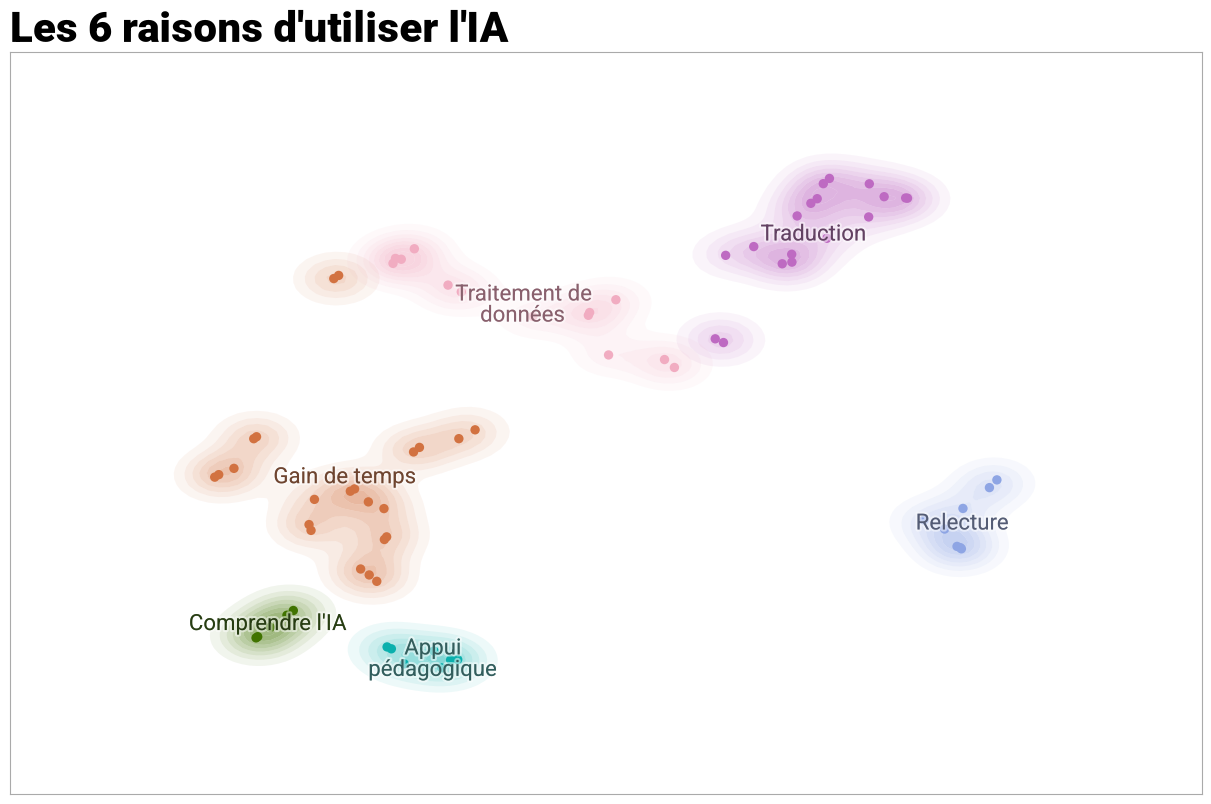

In [231]:
# with the original embeddings
fig = topic_model.visualize_document_datamap(texts, reduced_embeddings=reduced_embeddings,
                                             title=f"Les {len(set(topics))-1} raisons d'utiliser l'IA", custom_labels=True, 
                                             datamap_kwds={"label_font_size":16,"label_over_points":True, "dynamic_label_size":True})


In [232]:
fig.savefig("../script_analyse/stat_descriptive/viz/raison_ia_bertopic.png", bbox_inches="tight")

# Attribution des topics aux documents

In [235]:
# 1. Récupération des infos sur les documents avec .get_document_info(). On enlève les colonne superflues
dftexts = topic_model.get_document_info(texts)#.sort_values(by=["Topic","Probability"], ascending=[True, False])#.drop(columns=["CustomName", "Representative_document", "Representative_Docs", "Top_n_words"])
dftexts["text_id"] = "id_" + dftexts.index.astype(str)
dftexts


,Document,Topic,Name,CustomName,Representation,Representative_Docs,Top_n_words,Probability,Representative_document,text_id
0,pédagogie recherche biblio,3,3_correction_relectures_analyse documents_assi...,Relecture,"[correction, relectures, analyse documents, as...",[correction orthographique reformulation epice...,correction - relectures - analyse documents - ...,1.000000,False,id_0
1,relecture de anglais principalement,1,1_traduction_anglais_textes_traductions,Traduction,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...,traduction - anglais - textes - traductions - ...,1.000000,False,id_1
2,aide ponctuelle formulation de traduction aide...,1,1_traduction_anglais_textes_traductions,Traduction,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...,traduction - anglais - textes - traductions - ...,0.704998,True,id_2
3,principalement pour alléger ma charge de trava...,0,0_temps_gagner temps_gagner_informations,Gain de temps,"[temps, gagner temps, gagner, informations, pr...",[principalement pour des aides à la programmat...,temps - gagner temps - gagner - informations -...,1.000000,True,id_3
4,intelligence artificielle désigne de nombreuse...,0,0_temps_gagner temps_gagner_informations,Gain de temps,"[temps, gagner temps, gagner, informations, pr...",[principalement pour des aides à la programmat...,temps - gagner temps - gagner - informations -...,0.726903,False,id_4
...,...,...,...,...,...,...,...,...,...,...
69,gagner du temps,0,0_temps_gagner temps_gagner_informations,Gain de temps,"[temps, gagner temps, gagner, informations, pr...",[principalement pour des aides à la programmat...,temps - gagner temps - gagner - informations -...,1.000000,False,id_69
70,traduction amélioration de écriture reformulat...,1,1_traduction_anglais_textes_traductions,Traduction,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...,traduction - anglais - textes - traductions - ...,0.716208,False,id_70
71,beaucoup plus rapide et plus précise que scopu...,0,0_temps_gagner temps_gagner_informations,Gain de temps,"[temps, gagner temps, gagner, informations, pr...",[principalement pour des aides à la programmat...,temps - gagner temps - gagner - informations -...,1.000000,False,id_71
72,revision de anglais écrit traduction et analys...,1,1_traduction_anglais_textes_traductions,Traduction,"[traduction, anglais, textes, traductions, aid...",[aide ponctuelle formulation de traduction aid...,traduction - anglais - textes - traductions - ...,1.000000,False,id_72


In [236]:
for x in dftexts.Document.loc[dftexts.Topic==0]:
    print(x)

principalement pour alléger ma charge de travail rechercher des informations méthodologique ou statistiques relire ma production en anglais améliorer des formulations rédiger des mails de réponse rédiger des post professionnels pour les réseaux sociaux etc
intelligence artificielle désigne de nombreuses technologies
il agit de logiciels qui tournent en local sur mon matériel
il agit de mon coeur de recherche
pour rester au courant des progrès et fonctionnalités
deepl objection de conscience par rapport à ia générative
pour de la recherche de documents ou de processus
formidable gain de temps pour de nombreuses dimensions du travail universitaire
principalement pour gagner du temps sur des tâches administratives écriture de mails certaines parties des dossiers aap parfois pour reformulerou générer des données fictives pour mes cours cours de statistiques rarement pour rechercher de la littérature scientifique
traitement de données sourcing
pour gagner du temps synthétiser principalement

In [247]:
df_ia2 = df_ia1.merge(dftexts[["text_id","Topic","CustomName","Document"]], on =["text_id"], how = "left")
df_ia2

,index,q45_clé,q35_ia_tools,q37_raison_util_ia,text,clean_text,split_text,tokens,len_txt,text_id,Topic,CustomName,Document
0,2,FCCB-GMYA,"Chat GPT, Mistral IA, LM Notebook","Pédagogie, Recherche (biblio)","Pédagogie, Recherche (biblio)","pédagogie, recherche biblio",pédagogie recherche biblio,"[pédagogie, recherche, biblio]",3,id_0,3,Relecture,pédagogie recherche biblio
1,3,CV3G-95CT,"chatgpt, euria",relecture de l'anglais principalement,relecture de l'anglais principalement,relecture de anglais principalement,relecture de anglais principalement,"[relecture, de, anglais, principalement]",4,id_1,1,Traduction,relecture de anglais principalement
2,4,M5L8-UM9F,"Chat-GPT, Perplexity","aide ponctuelle formulation de traduction, aid...","aide ponctuelle formulation de traduction, aid...","aide ponctuelle formulation de traduction, aid...",aide ponctuelle formulation de traduction aide...,"[aide, ponctuelle, formulation, de, traduction...",13,id_2,1,Traduction,aide ponctuelle formulation de traduction aide...
3,8,9K9T-RVNL,le chat ; chatgpt,Principalement pour alléger ma charge de trava...,Principalement pour alléger ma charge de trava...,principalement pour alléger ma charge de trava...,principalement pour alléger ma charge de trava...,"[principalement, pour, alléger, ma, charge, de...",35,id_3,0,Gain de temps,principalement pour alléger ma charge de trava...
4,9,CN6B-UEHQ,Intelligence Artificielle désigne de nombreuse...,Il s'agit de mon cœur de recherche.,Intelligence Artificielle désigne de nombreuse...,intelligence artificielle désigne de nombreuse...,intelligence artificielle désigne de nombreuse...,"[intelligence, artificielle, désigne, de, nomb...",6,id_4,0,Gain de temps,intelligence artificielle désigne de nombreuse...
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,109,RZY3-LPES,"Chat GPT, IA associée aux App (dont Apple IA)",Gagner du temps +++,Gagner du temps +++,gagner du temps ...,gagner du temps,"[gagner, du, temps]",3,id_69,0,Gain de temps,gagner du temps
70,111,Q934-QKAW,Chat GPT ; Claude,"traduction, amélioration de l'écriture, reform...","traduction, amélioration de l'écriture, reform...","traduction, amélioration de écriture, reformul...",traduction amélioration de écriture reformulat...,"[traduction, amélioration, de, écriture, refor...",8,id_70,1,Traduction,traduction amélioration de écriture reformulat...
71,112,HKN6-95PQ,Elicit,Beaucoup plus rapide et plus précise que Scopu...,Beaucoup plus rapide et plus précise que Scopu...,beaucoup plus rapide et plus précise que scopu...,beaucoup plus rapide et plus précise que scopu...,"[beaucoup, plus, rapide, et, plus, précise, qu...",11,id_71,0,Gain de temps,beaucoup plus rapide et plus précise que scopu...
72,115,WAR9-LFJP,"Claude, ChatGPT",Revision de l'anglais écrit/traduction et anal...,Revision de l'anglais écrit/traduction et anal...,revision de anglais écrit traduction et analys...,revision de anglais écrit traduction et analys...,"[revision, de, anglais, écrit, traduction, et,...",10,id_72,1,Traduction,revision de anglais écrit traduction et analys...


In [257]:
for x in df_ia2.text.loc[df_ia2.Topic==4]:
    print(x)

Automatisation de tâches réccurentes, créations de site web pour des supports pédagogiques personnalisés en ligne.
Deep L, Coco SSD dans le cadre d'un projet de recherche, parfois Chat GPT pour tester les éventuels usages dans des travaux des étudiant.es. Traduction, recherche, contrôle
Pour m'aider à la conception d'exercices en cours, pour m'aider à faire des recherches web sur des sujets précis
très peu ; chat GPT mais je l'utilise très peu car ce n'est pas un compte pro; je préfère attendre que l'on ait des recommandations en terme d'utilisation de l'IA par l'université, avec peut être un compte pro pour protéger le contenu dépose ; j'utilise par contre deep pour une aide à la traduction. deepL pour la traduction ; chat GPT ponctuellement pour des questions générales
Comprendre et anticiper la façon dont les étudiants les utilisent
Enseignement: Structuration de cours, élaboration de syllabus, idées d'activités pédagogiques; Recherche: aide à la reformulation d'idées
Je participe à